<a href="https://colab.research.google.com/github/ArvindKumar29/Isomorphic_twin_copy/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

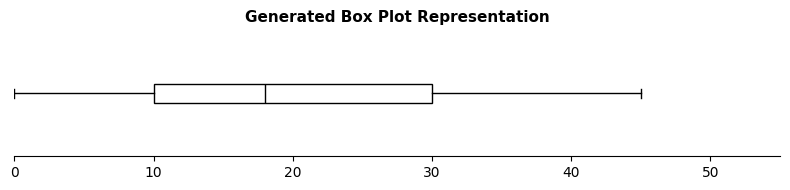

{
    "question": "The box plot below represents a distribution of continuous dataset values. What is the interquartile range (IQR) of the set of data?",
    "latex_formula": "$IQR = Q_3 - Q_1$",
    "options": {
        "A": 45,
        "B": 20,
        "C": 30,
        "D": 30
    },
    "correct_answer": "B",
    "correct_value": 20,
    "explanation": "The interquartile range (IQR) measures the statistical dispersion, representing the middle 50% of scores ($Q_3 - Q_1$). From the generated box plot, the lower quartile ($Q_1$) is 10 and the upper quartile ($Q_3$) is 30. Therefore, calculation yields $IQR = 30 - 10 = 20$."
}


In [10]:

import random
import matplotlib.pyplot as plt
import json

def generate_isomorphic_twin():
    q1 = random.choice([10, 15, 20, 25])
    iqr = random.choice([10, 15, 20, 25])
    q3 = q1 + iqr

    min_val = max(0, q1 - random.choice([5, 10]))
    max_val = q3 + random.choice([10, 15, 20])
    median = random.randint(q1 + 2, q3 - 2)

    correct_answer = iqr

    distractors = [
        q3,
        max_val - min_val,
        abs(q3 - min_val),
        iqr + random.choice([-5, 5])
    ]
    distractors = [d for d in distractors if d != correct_answer and d > 0]
    while len(distractors) < 3:
        d = correct_answer + random.choice([-10, 10, 5])
        if d > 0 and d != correct_answer and d not in distractors:
            distractors.append(d)

    options_pool = [correct_answer] + distractors[:3]
    random.shuffle(options_pool)

    option_labels = ['A', 'B', 'C', 'D']
    options_dict = {}
    correct_option_label = ''

    for label, opt in zip(option_labels, options_pool):
        options_dict[label] = opt
        if opt == correct_answer:
            correct_option_label = label

    # Generate and display the box plot directly in Colab
    fig, ax = plt.subplots(figsize=(8, 2))

    stats = {
        'med': median,
        'q1': q1,
        'q3': q3,
        'whislo': min_val,
        'whishi': max_val,
        'fliers': []
    }

    ax.bxp([stats], vert=False, patch_artist=True,
           boxprops=dict(facecolor='white', edgecolor='black'),
           medianprops=dict(color='black'),
           whiskerprops=dict(color='black'),
           capprops=dict(color='black'))

    ax.set_xlim(0, max_val + 10)
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')

    plt.title("Generated Box Plot Representation", fontsize=11, fontweight='bold')
    plt.tight_layout()

    # This will show the image right on your phone screen in Colab
    plt.show()

    output_package = {
        "question": "The box plot below represents a distribution of continuous dataset values. What is the interquartile range (IQR) of the set of data?",
        "latex_formula": "$IQR = Q_3 - Q_1$",
        "options": options_dict,
        "correct_answer": correct_option_label,
        "correct_value": correct_answer,
        "explanation": f"The interquartile range (IQR) measures the statistical dispersion, representing the middle 50% of scores ($Q_3 - Q_1$). From the generated box plot, the lower quartile ($Q_1$) is {q1} and the upper quartile ($Q_3$) is {q3}. Therefore, calculation yields $IQR = {q3} - {q1} = {correct_answer}$."
    }

    return output_package

if __name__ == "__main__":
    result = generate_isomorphic_twin()
    print(json.dumps(result, indent=4))